In [31]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.optimize as spyo
import matplotlib.pyplot as plt
url="https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
SP500=pd.read_html(url,storage_options={"User-Agent":"Mozzilla/5.0"})[0]
Companies=SP500['Symbol'].str.replace('.','-').tolist()
RealisationMatrix=yf.download(Companies,period='5y')['Close']

[*********************100%***********************]  503 of 503 completed


In [32]:
#denoising Matrix
Clean=RealisationMatrix.dropna(axis=1)
Returns=np.log(Clean/Clean.shift(1)).dropna()
split=int(len(Returns)*0.8)
Returns_train=Returns.iloc[:split]
Returns_test=Returns.iloc[split:]
StandardizedReturns_train=(Returns_train-Returns_train.mean())/Returns_train.std()
X=StandardizedReturns_train.to_numpy()
T,N=X.shape
E=1/T * np.dot(X.T, X) #Empirical Correlation Matrix
Evals,Evecs=np.linalg.eigh(E)
lambdaplus=(1+np.sqrt(N/T))**2 #Marchenko-Pastur Bound
#Treating eigenvalues lying in MP bounds as noise
signal=Evals>lambdaplus
mean_noise=np.mean(Evals[~signal])
EvalsClean=Evals.copy()
EvalsClean[~signal]=mean_noise #Replacing noise eigenvalues with their mean
EClean=Evecs@np.diag(EvalsClean)@Evecs.T #Variance/covariance matrix
Variances=np.diag(EClean)
EClean=np.outer(1/np.sqrt(Variances),1/np.sqrt(Variances))*EClean #Denoised/CLeaned Correlation Matrix

In [33]:
#clean vs raw MSR
def sharperatio(w,mu,Sigma,rf=0.04):
    numerator=np.dot(w,mu)-rf
    denominator=np.sqrt(np.dot(w,np.dot(Sigma,w)))
    sharpe=numerator/denominator
    return -sharpe #minus since we are minimising
    
SD_yearly=Returns_train.std().to_numpy()*np.sqrt(252)
mu_yearly=Returns_train.mean().to_numpy()*252
CleanSIGMA=np.diag(SD_yearly)@EClean@np.diag(SD_yearly)
RawSIGMA=np.diag(SD_yearly)@E@np.diag(SD_yearly)

initial=np.ones(N)/N 
bounds=[(0,1) for _ in range(N)]
constraints= {'type':'eq','fun':lambda w:np.sum(w)-1}
optimise_clean=spyo.minimize(fun=sharperatio,x0=initial,args=(mu_yearly,CleanSIGMA),
                                method='SLSQP',bounds=bounds,constraints=constraints)
optimise_raw=spyo.minimize(fun=sharperatio,x0=initial,args=(mu_yearly,RawSIGMA),
                              method='SLSQP',bounds=bounds,constraints=constraints)

wclean=optimise_clean.x
wraw=optimise_raw.x
test_returns_matrix = Returns_test.to_numpy()
daily_ret_clean = test_returns_matrix @ wclean
daily_ret_raw = test_returns_matrix @ wraw
rf_daily = 0.04 / 252
sharpe_out_clean = (np.mean(daily_ret_clean)-rf_daily)/np.std(daily_ret_clean)*np.sqrt(252)
sharpe_out_raw = (np.mean(daily_ret_raw)-rf_daily)/np.std(daily_ret_raw)*np.sqrt(252)

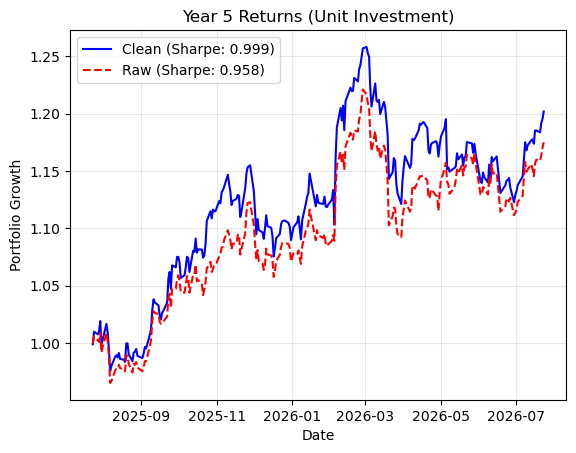

In [34]:
growth_clean = (1 + daily_ret_clean).cumprod()
growth_raw = (1 + daily_ret_raw).cumprod()

plt.plot(Returns_test.index, growth_clean, label=f'Clean (Sharpe: {sharpe_out_clean:.3f})', color='blue')
plt.plot(Returns_test.index, growth_raw, label=f'Raw (Sharpe: {sharpe_out_raw:.3f})', color='red', linestyle='--')
plt.title('Year 5 Returns (Unit Investment)')
plt.xlabel('Date')
plt.ylabel('Portfolio Growth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()